In [13]:

from transformers import AutoTokenizer
from datasets import load_dataset, Dataset
import pandas as pd
import numpy as np

# All models to compare
model_names = [
    "google/gemma-3-1b-pt",
    #"google/gemma-3-1b-it",
    "meta-llama/Llama-3.2-1B",
    #"meta-llama/Llama-3.2-1B-Instruct",
    "Qwen/Qwen2.5-1.5B",
    #"Qwen/Qwen2.5-1.5B-Instruct"
]

# Load Romanian dataset
ro_ds = Dataset.load_from_disk('../data/mixed_milestone_dataset')
print(f"Loaded Romanian dataset: {len(ro_ds)} examples")

Loaded Romanian dataset: 219505 examples


In [14]:
import re
def remove_instruction_tokens(text):
    """Remove instruction-tuning special tokens from text"""
    # Llama3 instruction tokens
    patterns = [
        r'<\|start_header_id\|>.*?<\|end_header_id\|>',
        r'<\|eot_id\|>',
        r'<\|begin_of_text\|>',
        r'<\|end_of_text\|>',
        # Gemma tokens
        r'<start_of_turn>.*?<end_of_turn>',
        r'<bos>',
        r'<eos>',
        # General patterns
        r'<\|.*?\|>',
    ]
    
    cleaned = text
    for pattern in patterns:
        cleaned = re.sub(pattern, '', cleaned, flags=re.DOTALL)
    
    # Remove extra whitespace
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

# Clean Romanian text
ro_texts = []
for example in ro_ds.select(range(min(500, len(ro_ds)))):  # Use first 500 examples
    text = example.get('formatted_text', '')
    cleaned = remove_instruction_tokens(text)
    if cleaned:  # Only add non-empty text
        ro_texts.append(cleaned)

print(f"Cleaned {len(ro_texts)} Romanian examples")
print(f"Sample cleaned text:\n{ro_texts[0][:200]}...")

Cleaned 500 Romanian examples
Sample cleaned text:
Acest curs, care este obligatoriu pentru toți studenții la relații internaționale, include următoarele subiecte: sociologia politică, politicile externe ale marilor puteri, dreptul internațional, poli...


In [15]:
# Load English dataset for comparison (Alpaca)
try:
    en_ds = load_dataset("tatsu-lab/alpaca", split="train")
    en_texts = []
    for example in en_ds.select(range(min(500, len(en_ds)))):
        # Combine instruction and output for full text
        text = f"{example['instruction']} {example['output']}"
        if text.strip():
            en_texts.append(text.strip())
    print(f"Loaded {len(en_texts)} English examples from Alpaca")
    print(f"Sample English text:\n{en_texts[0][:200]}...")
except Exception as e:
    print(f"Error loading Alpaca: {e}")
    print("Using fallback English dataset...")
    # Fallback to a simpler dataset
    en_ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
    en_texts = [text for text in en_ds['text'][:500] if len(text.split()) > 10]
    print(f"Loaded {len(en_texts)} English examples from Wikitext")

Loaded 500 English examples from Alpaca
Sample English text:
Give three tips for staying healthy. 1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep an...


In [16]:
def analyze_tokenization(tokenizer, texts, language=""):
    """Calculate tokenization efficiency metrics"""
    total_tokens = 0
    total_words = 0
    total_chars = 0
    
    for text in texts:
        # Tokenize
        tokens = tokenizer.encode(text, add_special_tokens=False)
        words = text.split()
        
        total_tokens += len(tokens)
        total_words += len(words)
        total_chars += len(text)
    
    return {
        'language': language,
        'num_examples': len(texts),
        'total_tokens': total_tokens,
        'total_words': total_words,
        'total_chars': total_chars,
        'tokens_per_word': total_tokens / total_words if total_words > 0 else 0,
        'chars_per_token': total_chars / total_tokens if total_tokens > 0 else 0,
        'words_per_token': total_words / total_tokens if total_tokens > 0 else 0
    }

print("Analysis functions ready!")

Analysis functions ready!


In [17]:
# Run tokenization comparison
results = []

for model_name in model_names:
    print(f"\n{'='*60}")
    print(f"Analyzing: {model_name}")
    print(f"{'='*60}")
    
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    
    # Analyze Romanian
    ro_stats = analyze_tokenization(tokenizer, ro_texts, language="Romanian")
    ro_stats['model'] = model_name
    ro_stats['model_type'] = 'IT' if 'instruct' in model_name.lower() or '-it' in model_name.lower() else 'PT'
    results.append(ro_stats)
    
    print(f"  Romanian: {ro_stats['tokens_per_word']:.3f} tokens/word")
    
    # Analyze English
    en_stats = analyze_tokenization(tokenizer, en_texts, language="English")
    en_stats['model'] = model_name
    en_stats['model_type'] = 'IT' if 'instruct' in model_name.lower() or '-it' in model_name.lower() else 'PT'
    results.append(en_stats)
    
    print(f"  English:  {en_stats['tokens_per_word']:.3f} tokens/word")
    print(f"  Romanian/English ratio: {ro_stats['tokens_per_word'] / en_stats['tokens_per_word']:.3f}x")

print("\n" + "="*60)
print("Analysis complete!")
print("="*60)


Analyzing: google/gemma-3-1b-pt
  Romanian: 1.910 tokens/word
  English:  1.246 tokens/word
  Romanian/English ratio: 1.533x

Analyzing: meta-llama/Llama-3.2-1B
  Romanian: 2.201 tokens/word
  English:  1.236 tokens/word
  Romanian/English ratio: 1.780x

Analyzing: Qwen/Qwen2.5-1.5B
  Romanian: 2.236 tokens/word
  English:  1.247 tokens/word
  Romanian/English ratio: 1.792x

Analysis complete!


In [18]:
# Create comparison DataFrame
df = pd.DataFrame(results)

# Display results grouped by language
print("\n" + "="*80)
print("ROMANIAN TOKENIZATION EFFICIENCY")
print("="*80)
ro_df = df[df['language'] == 'Romanian'][['model', 'model_type', 'tokens_per_word', 'chars_per_token']].copy()
ro_df = ro_df.sort_values('tokens_per_word')
ro_df.index = range(1, len(ro_df) + 1)
print(ro_df.to_string())

print("\n" + "="*80)
print("ENGLISH TOKENIZATION EFFICIENCY")
print("="*80)
en_df = df[df['language'] == 'English'][['model', 'model_type', 'tokens_per_word', 'chars_per_token']].copy()
en_df = en_df.sort_values('tokens_per_word')
en_df.index = range(1, len(en_df) + 1)
print(en_df.to_string())


ROMANIAN TOKENIZATION EFFICIENCY
                     model model_type  tokens_per_word  chars_per_token
1     google/gemma-3-1b-pt         PT         1.909602         3.407345
2  meta-llama/Llama-3.2-1B         PT         2.201403         2.955694
3        Qwen/Qwen2.5-1.5B         PT         2.235576         2.910513

ENGLISH TOKENIZATION EFFICIENCY
                     model model_type  tokens_per_word  chars_per_token
1  meta-llama/Llama-3.2-1B         PT         1.236412         4.977888
2     google/gemma-3-1b-pt         PT         1.245567         4.941302
3        Qwen/Qwen2.5-1.5B         PT         1.247455         4.933823


In [19]:
# Calculate and display Romanian/English efficiency ratio
print("\n" + "="*80)
print("ROMANIAN vs ENGLISH TOKENIZATION RATIO")
print("="*80)
print("(Higher ratio = less efficient for Romanian compared to English)")
print("-"*80)

ratio_data = []
for model in model_names:
    ro_row = df[(df['model'] == model) & (df['language'] == 'Romanian')].iloc[0]
    en_row = df[(df['model'] == model) & (df['language'] == 'English')].iloc[0]
    
    ratio = ro_row['tokens_per_word'] / en_row['tokens_per_word']
    model_type = ro_row['model_type']
    
    ratio_data.append({
        'model': model,
        'model_type': model_type,
        'ro_tokens_per_word': ro_row['tokens_per_word'],
        'en_tokens_per_word': en_row['tokens_per_word'],
        'ratio': ratio
    })

ratio_df = pd.DataFrame(ratio_data).sort_values('ratio')
ratio_df.index = range(1, len(ratio_df) + 1)
print(ratio_df.to_string())

# Summary statistics
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
best_ro = ro_df.iloc[0]
worst_ro = ro_df.iloc[-1]
best_ratio = ratio_df.iloc[0]

print(f"✓ Best Romanian tokenization: {best_ro['model']}")
print(f"  → {best_ro['tokens_per_word']:.3f} tokens/word, {best_ro['chars_per_token']:.2f} chars/token")
print(f"\n✗ Worst Romanian tokenization: {worst_ro['model']}")
print(f"  → {worst_ro['tokens_per_word']:.3f} tokens/word, {worst_ro['chars_per_token']:.2f} chars/token")
print(f"\n★ Most Romanian-friendly tokenizer: {best_ratio['model']}")
print(f"  → {best_ratio['ratio']:.3f}x ratio (closer to 1.0 = better Romanian support)")


ROMANIAN vs ENGLISH TOKENIZATION RATIO
(Higher ratio = less efficient for Romanian compared to English)
--------------------------------------------------------------------------------
                     model model_type  ro_tokens_per_word  en_tokens_per_word     ratio
1     google/gemma-3-1b-pt         PT            1.909602            1.245567  1.533119
2  meta-llama/Llama-3.2-1B         PT            2.201403            1.236412  1.780477
3        Qwen/Qwen2.5-1.5B         PT            2.235576            1.247455  1.792110

KEY INSIGHTS
✓ Best Romanian tokenization: google/gemma-3-1b-pt
  → 1.910 tokens/word, 3.41 chars/token

✗ Worst Romanian tokenization: Qwen/Qwen2.5-1.5B
  → 2.236 tokens/word, 2.91 chars/token

★ Most Romanian-friendly tokenizer: google/gemma-3-1b-pt
  → 1.533x ratio (closer to 1.0 = better Romanian support)


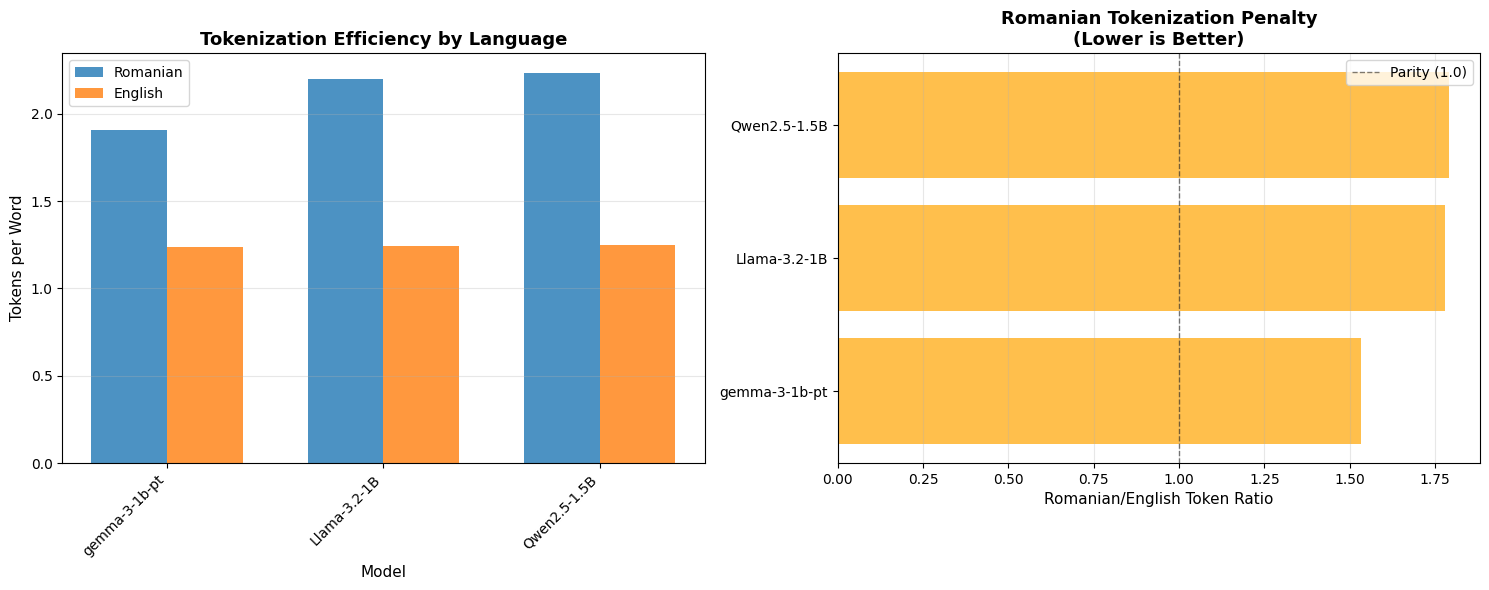

In [20]:
# Optional: Visualize the comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Tokens per word by language
ax1 = axes[0]
ro_data = df[df['language'] == 'Romanian'].sort_values('tokens_per_word')
en_data = df[df['language'] == 'English'].sort_values('tokens_per_word')

x = np.arange(len(model_names))
width = 0.35

# Extract short model names for labels
short_names = [m.split('/')[-1] for m in ro_data['model']]

bars1 = ax1.bar(x - width/2, ro_data['tokens_per_word'], width, label='Romanian', alpha=0.8)
bars2 = ax1.bar(x + width/2, en_data['tokens_per_word'], width, label='English', alpha=0.8)

ax1.set_xlabel('Model', fontsize=11)
ax1.set_ylabel('Tokens per Word', fontsize=11)
ax1.set_title('Tokenization Efficiency by Language', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(short_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Romanian/English ratio
ax2 = axes[1]
ratio_sorted = ratio_df.sort_values('ratio')
short_names_ratio = [m.split('/')[-1] for m in ratio_sorted['model']]
colors = ['green' if r < 1.5 else 'orange' if r < 2.0 else 'red' for r in ratio_sorted['ratio']]

bars = ax2.barh(range(len(ratio_sorted)), ratio_sorted['ratio'], color=colors, alpha=0.7)
ax2.set_yticks(range(len(ratio_sorted)))
ax2.set_yticklabels(short_names_ratio)
ax2.set_xlabel('Romanian/English Token Ratio', fontsize=11)
ax2.set_title('Romanian Tokenization Penalty\n(Lower is Better)', fontsize=13, fontweight='bold')
ax2.axvline(x=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Parity (1.0)')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()